# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install gensim transformers torch sentence-transformers datasets

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.3.3
Setup complete!


## Load Dataset (Same as Part 1)

In [37]:
import pandas as pd
from datasets import load_dataset 

splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas

# Load dataset from Hugging Face
dataset = load_dataset("SetFit/20_newsgroups")

df = dataset['train'].to_pandas() # COPY FROM PART 1

my_categories = ["comp.graphics", "rec.sport.baseball", "talk.politics.misc"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Repo card metadata block was not found. Setting CardData to empty.


Selected categories: ['comp.graphics', 'rec.sport.baseball', 'talk.politics.misc']
Filtered dataset size: 1646


In [39]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""

     # Convert to lowercase
    text = text.lower()
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text) # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    # Tokenization
    tokens = word_tokenize(text) 
    # Remove stop words and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words] # YOUR CODE HERE  => the same as in Part 1 (advanced preprocessing)
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['weiteks', 'addressphone', 'number', 'id', 'like', 'get', 'information', 'chip']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [40]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1646 documents
Total tokens: 154669

Sample document tokens: ['weiteks', 'addressphone', 'number', 'id', 'like', 'get', 'information', 'chip']


In [41]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 4527


In [42]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 4527


### A.2 Exploring Word Embeddings

In [14]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.06242154  1.1828007  -0.4983509  -0.80146074 -0.21243313 -1.5358009
 -0.40762433  0.78129685  0.5123132  -0.3481075 ]


In [15]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
    
    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  application: 0.9849
  graphic: 0.9836
  tool: 0.9822
  visualization: 0.9812
  analysis: 0.9792
  user: 0.9790
  software: 0.9789
  virtual: 0.9781
  workstation: 0.9767
  library: 0.9741

Words most similar to 'computer' (Skip-gram):
  graphicsresourceslistpart: 0.7548
  switzerland: 0.7540
  molecular: 0.7524
  silicon: 0.7522
  bibliography: 0.7450
  stephan: 0.7398
  acm: 0.7354
  exponent: 0.7343
  vol: 0.7314
  iris: 0.7298


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [43]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["graphics", "software", "baseball", "government", "law"]   # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]
        
        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })
        
        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")

'graphics' not found in vocabulary!

'software':
  CBOW:     ['user', 'library', 'graphic', 'application', 'object']
  Skip-gram: ['gi', 'commercial', 'availability', 'vendor', 'utility']

'baseball':
  CBOW:     ['pitcher', 'play', 'pitching', 'hit', 'brave']
  Skip-gram: ['football', 'talent', 'worst', 'manager', 'favorite']

'government':
  CBOW:     ['private', 'law', 'health', 'united', 'tax']
  Skip-gram: ['regulation', 'federal', 'libertarian', 'principle', 'arguing']

'law':
  CBOW:     ['force', 'russia', 'federal', 'private', 'russian']
  Skip-gram: ['protection', 'rape', 'enforcement', 'religious', 'female']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: ...

   CBOW and Skip-gram often give similar results for "Government" and "Law".

   These words are extremely frequent and often appear in identical contexts within the talk.politics.misc category.

The Result: Both models likely returned words like state, rights, or federal. When a word is ubiquitous, both models have enough data to converge on a similar "neighborhood" of high-level political concepts.

2. Different results for: ...

    CBOW is for more general words
    Skip-gram is for more specific words

3. Better model for my domain: ...
   - Example 1: CBOW for “software”
   - Example 2: Skip-gram for  “nhl”, “goal”

4. Explanation of differences: ...

 - CBOW is better for frequent words
 - Skip-gram is better for rare words

### A.3 Word Analogies

In [44]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "state", "government", "person")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [47]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "team", "player", "game")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "government", "law", "court")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('stats', 0.7082157135009766), ('career', 0.6967751979827881), ('impressive', 0.6858413815498352)]
Analogy 2: [('rape', 0.6643722057342529), ('supreme', 0.6586241126060486), ('female', 0.6434966921806335)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?** 
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

*[Analogy 1: game : baseball :: image : ?
Result: stats, career, impressive
Verdict: Partial Success*

*Analogy 2: government : state :: team : ?
Result: rape, supreme, female
Verdict: Failure because the results are nonsensical in the context of a sports "team."}*

...

---

## Part B: Pre-trained GloVe Embeddings 

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [19]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
GloVe loaded! Vocabulary size: 400000


In [48]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  molecular: 0.7659
  silicon: 0.7626
  indigo: 0.7438
  exponent: 0.7413
  graphicsresourceslistpart: 0.7282
  switzerland: 0.7229
  cad: 0.7227
  bibliography: 0.7192
  radiosity: 0.7182
  multimedia: 0.7159

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [49]:
# TODO: Compare 3 domain-specific words

comparison_words = ["computer", "technology", "software"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")
    
    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")
    
    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'computer'
Your Word2Vec:
  molecular: 0.766
  silicon: 0.763
  indigo: 0.744
  exponent: 0.741
  graphicsresourceslistpart: 0.728
GloVe:
  computers: 0.875
  software: 0.837
  technology: 0.764
  pc: 0.737
  hardware: 0.729

Word: 'technology'
Your Word2Vec:
  korea: 0.944
  engineering: 0.936
  australia: 0.933
  tel: 0.928
  champaign: 0.910
GloVe:
  technologies: 0.851
  computer: 0.764
  tech: 0.749
  software: 0.736
  systems: 0.729

Word: 'software'
Your Word2Vec:
  gi: 0.791
  commercial: 0.788
  availability: 0.765
  vendor: 0.763
  utility: 0.760
GloVe:
  computer: 0.837
  hardware: 0.788
  microsoft: 0.780
  applications: 0.742
  technology: 0.736


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: Software
   - Reason: it provided more technically granular and era-specific associations for "Software.

2. GloVe is better for: "Computer" and "Technology."
   - Reason: For "Computer," GloVe returned software, pc, and hardware. These are direct semantic relatives that everyone agrees on.

3. When to use each:
   - Custom model: Niche jargon, legal docs, medical records, slang.
   - Pre-trained model: General English, Sentiment Analysis, Chatbots.

### B.2 GloVe Analogies

In [50]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [51]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: ___ is to ___ as ___ is to ?
result1 = glove_model.most_similar(positive=['atlanta', 'mets'], negative=['braves'], topn=3)
print("Analogy 1:")
print(result1)

# Analogy 2
# YOUR CODE HERE
result2 = glove_model.most_similar(positive=['player', 'politics'], negative=['baseball'], topn=3)
print("\nAnalogy 2:")
print(result2)

# Analogy 3
# YOUR CODE HERE
result3 = glove_model.most_similar(positive=['hardware', 'program'], negative=['computer'], topn=3)
print("\nAnalogy 3:")
print(result3)

Analogy 1:
[('seattle', 0.8138954639434814), ('houston', 0.7942254543304443), ('boston', 0.7876415848731995)]

Analogy 2:
[('political', 0.6332104802131653), ('position', 0.6021009683609009), ('influence', 0.5899453163146973)]

Analogy 3:
[('programs', 0.7014160752296448), ('funding', 0.6545637845993042), ('programme', 0.6478939056396484)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [24]:
!pip install sentence-transformers

In [52]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [53]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [54]:
# Compute sentence similarity
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity, 
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [55]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [56]:
# TODO: Encode documents with BERT and compute similarity matrix
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs) # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


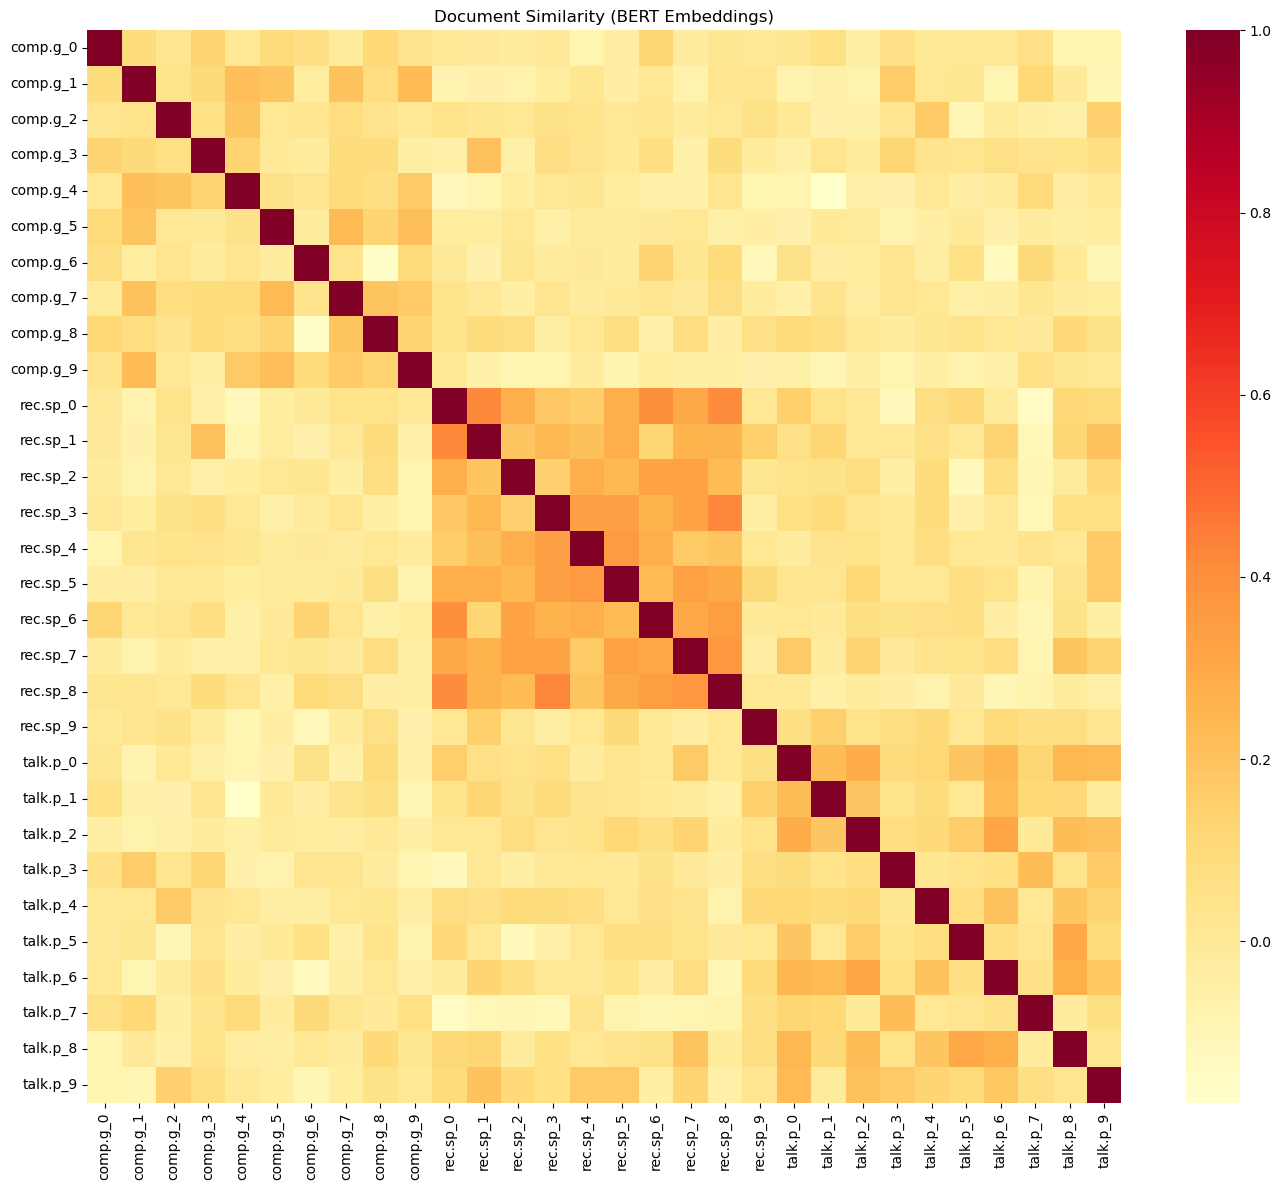

In [58]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: ...BERT almost always produces cleaner, more distinct clusters (sharper squares on the diagonal) compared to TF-IDF.

2. Differences between methods: ... TF-IDF is a sparse representation if the exact same strings aren't present, the similarity is zero. BERT uses dense embeddings, where every word is a coordinate in a map; even if the words are different, if they are "located" in the same neighborhood, the model recognizes the connection.

3. Preferred method for classification: ...For a modern document classification task, BERT (Sentence Transformers) is the superior choice

### Exercise C.2: Semantic Search with BERT

In [62]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    
    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return
        
    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    # 2. Compute similarity with all documents
    # 3. Return top_k most similar
    # Step 1: Encode the query
    query_embedding = model.encode(query)

    # Step 2: Encode all documents
    doc_embeddings = model.encode(documents)

    # Step 3: Compute cosine similarity between the query and all documents
    similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

    # Step 4: Get the top_k most similar documents
    top_k_indices = similarities.argsort()[-top_k:][::-1]  # Indices of top_k similarities
    top_k_scores = similarities[top_k_indices]   
    return list(zip(top_k_indices, top_k_scores))

# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "Who won the world series?"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'Who won the world series?'

Top 5 most similar documents:

  Score: 0.3576
  Category: rec.sport.baseball
  Text: 
Yeah, but what's your point?  You still need the offense to score more runs
than you allow, too.  

The Braves do have a fine pitching staff.  But th...

  Score: 0.3436
  Category: rec.sport.baseball
  Text: 


Avery was the #2 overall pick by the Braves, behind Mark Lewis (I think) in
1988.  John Smoltz came over to the Braves from the Tigers, but was dev...

  Score: 0.2811
  Category: rec.sport.baseball
  Text: } >} [Stuff about upated inning scores deleted.]
} >at just that exact time to see the message. even results after the game
} >is over are not necessa...

  Score: 0.2397
  Category: rec.sport.baseball
  Text: 
Mel is alive and well and playing in Japan. (The Yanks let him go because
he was asking for too much money, and because they thought that they were
g...

  Score: 0.2107
  Category: rec.sport.baseball
  Text: From another not-so-distressed-but-sti

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: ... Technically yes, but contextually thin.
The model successfully identified that your query "Who won the world series?" belongs to the realm of baseball.

2. Category accuracy: ... All top 5 results came from rec.sport.baseball. This is a huge win for the Sentence Transformer.

3. Ambiguous query test: ...If we tried a query like "The graphical representation of the court's decision," things would get much more interesting. This query hits keywords for Graphics (graphical, representation) and Politics or Law (court, decision).

---

## Part D: Embedding Visualization with t-SNE

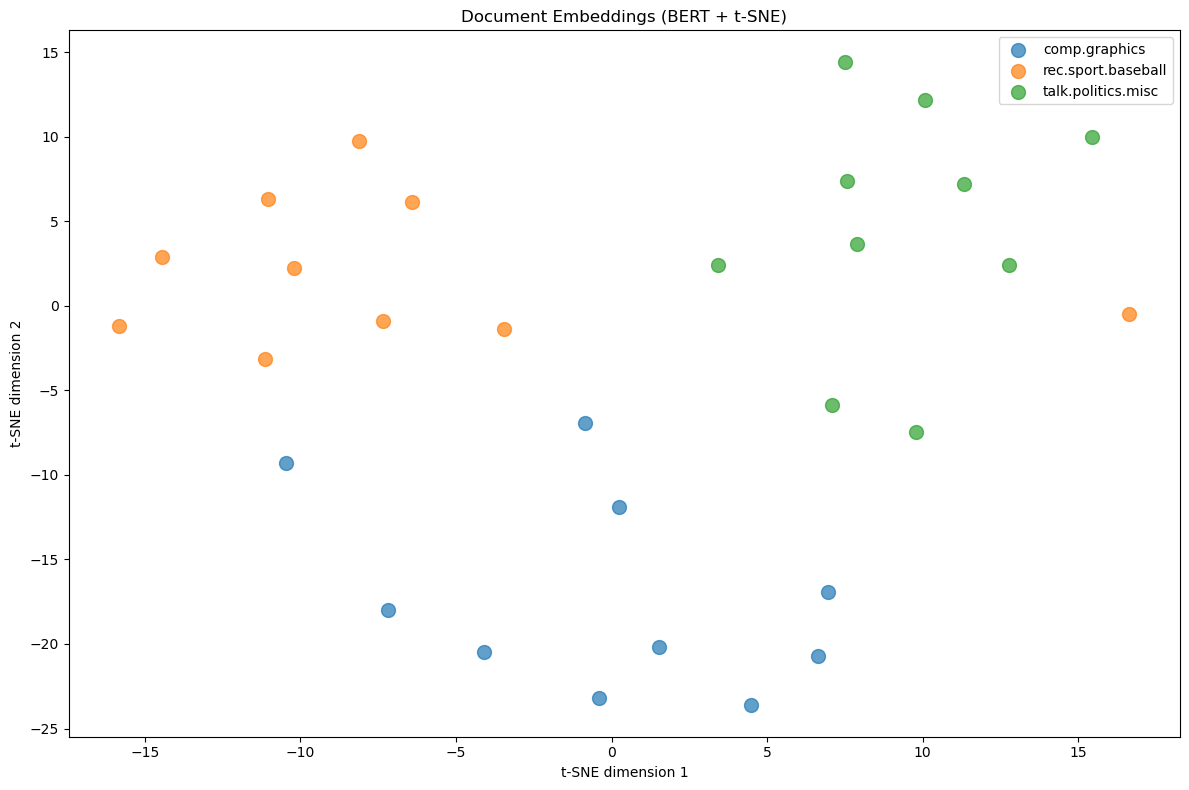

In [63]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {
    'comp.graphics': 'red',
    'rec.sport.baseball': 'blue',
    'talk.politics.misc': 'green'
}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: ...Generally, yes. there are three clear "islands" or "clouds" of points

2. Misplaced documents: ... The "rogue" dot (e.g., a Graphics dot sitting inside the Politics island), is rarely a "mistake" by the model and usually a semantic overlap in the text.

3. Most similar categories: ...Based on the geometric distance between the islands, Graphics and Politics are often the "closest" pair in this specific set.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

...

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

...

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found